# Task 2.1: Visualize Outliers with Boxplots

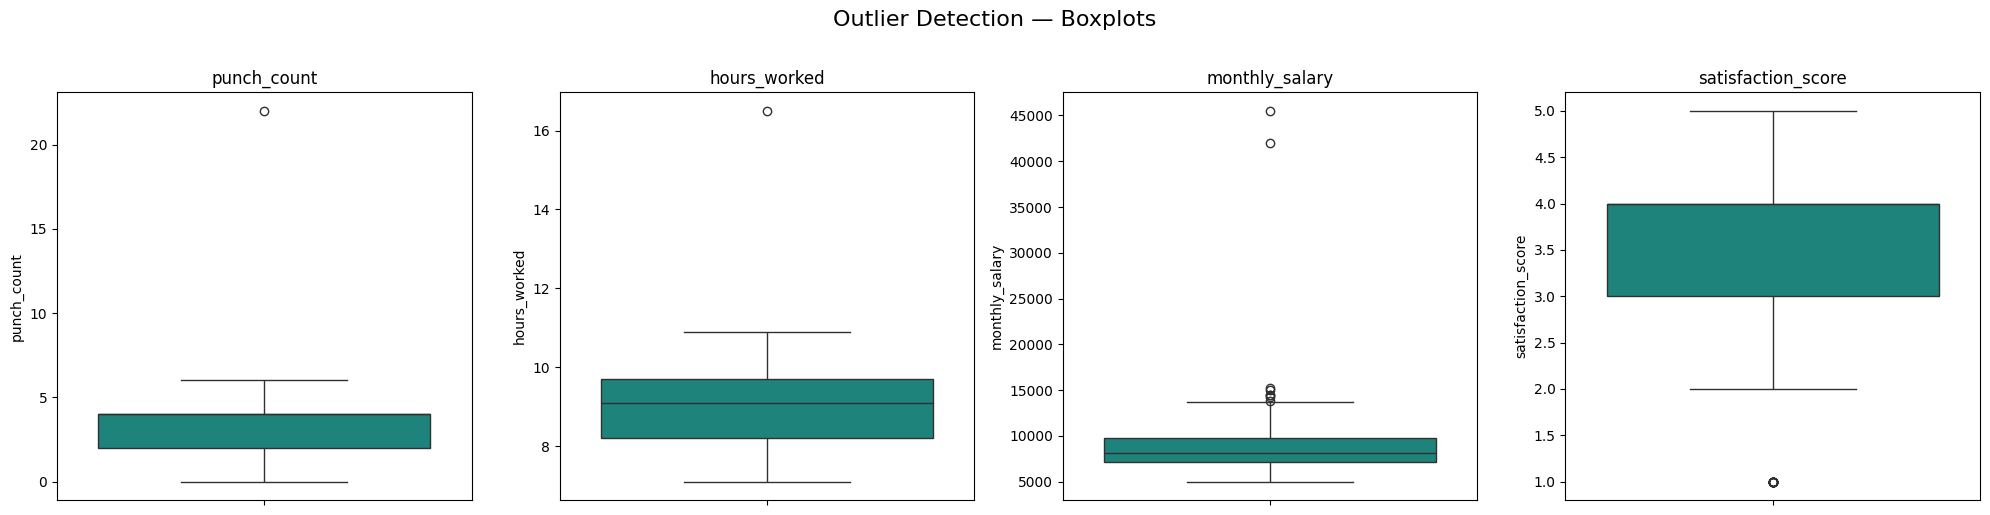

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('Practice_Dataset.xlsx')

# Exclude binary/flag columns (e.g. is_absent) — IQR/Z-score outlier
# methods only make sense for continuous variables.
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = [c for c in numeric_cols if df[c].nunique() > 2]

n_cols = len(numeric_cols)
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))
if n_cols == 1: axes = [axes]

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color='#0D9488')
    ax.set_title(col)

plt.suptitle('Outlier Detection — Boxplots', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# Task 2.2: IQR Method

In [3]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return outliers, lower, upper

for col in numeric_cols:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    if len(outliers) > 0:
        print(f'{col}: {len(outliers)} outliers (range: {lower:.2f} to {upper:.2f})')
    else:
        print(f'{col}: No outliers')

punch_count: 1 outliers (range: -1.00 to 7.00)
hours_worked: 1 outliers (range: 5.95 to 11.95)
monthly_salary: 8 outliers (range: 3069.75 to 13839.75)
satisfaction_score: 19 outliers (range: 1.50 to 5.50)


# Task 2.3: Z-Score Method

In [4]:
from scipy import stats

for col in numeric_cols:
    z_scores = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (z_scores > 3).sum()
    print(f'{col}: {outlier_count} outliers (Z > 3)' if outlier_count > 0 else f'{col}: no outliers (Z > 3)')

punch_count: 1 outliers (Z > 3)
hours_worked: 1 outliers (Z > 3)
monthly_salary: 2 outliers (Z > 3)
satisfaction_score: no outliers (Z > 3)


# Task 2.4: Treat Outliers — Capping & Transformation

punch_count: capped 1 outliers to [-1.00, 7.00]
hours_worked: capped 1 outliers to [5.95, 11.95]
monthly_salary: capped 8 outliers to [3069.75, 13839.75]
satisfaction_score: capped 19 outliers to [1.50, 5.50]


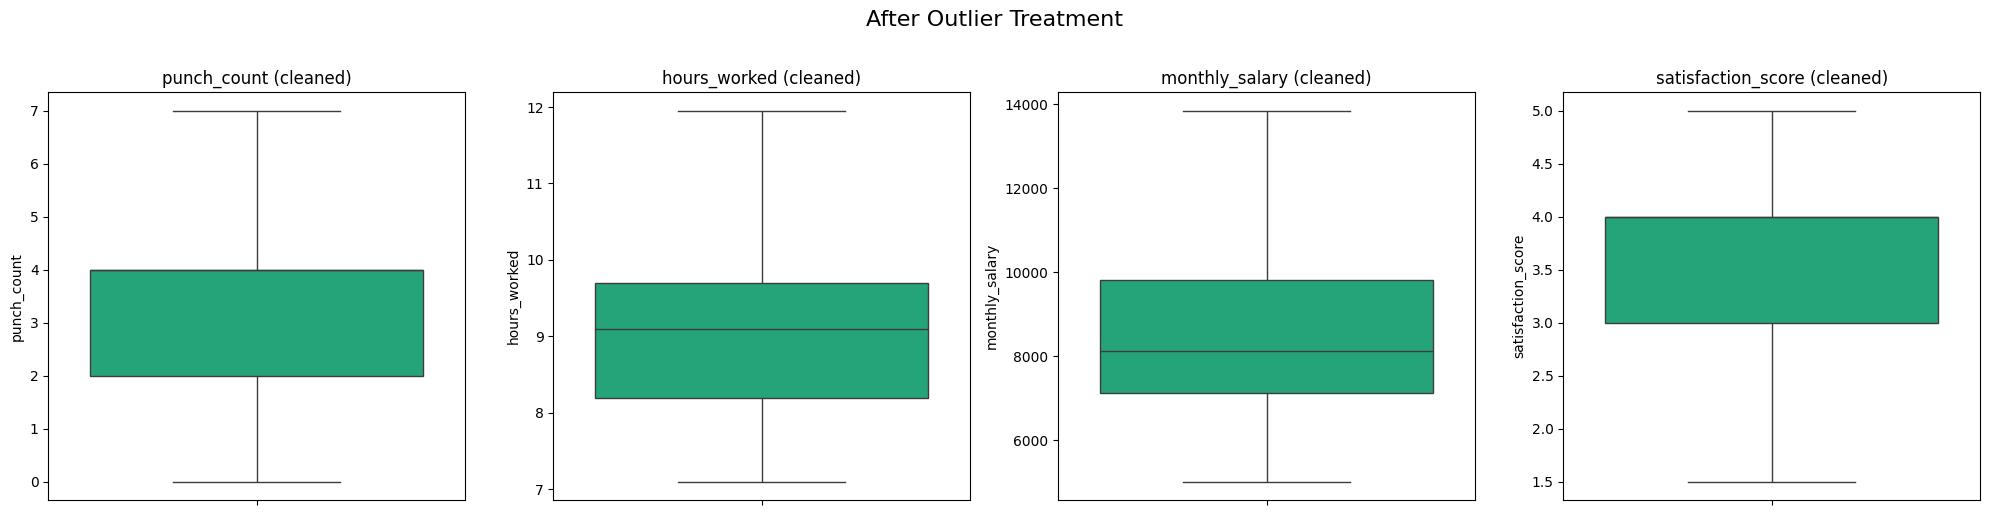

In [6]:
df_clean = df.copy()

def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(df[(df[column] < lower) | (df[column] > upper)])
    df[column] = df[column].clip(lower=lower, upper=upper)
    print(f'{column}: capped {before} outliers to [{lower:.2f}, {upper:.2f}]')

# Only cap continuous columns — is_absent stays untouched
for col in numeric_cols:
    cap_outliers(df_clean, col)

# Verify with boxplots after treatment
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5*len(numeric_cols), 5))
if len(numeric_cols) == 1: axes = [axes]
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df_clean[col], ax=ax, color='#10B981')
    ax.set_title(f'{col} (cleaned)')
plt.suptitle('After Outlier Treatment', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('boxplots_after.png', dpi=150, bbox_inches='tight')
plt.show()

#  Task 2.5 — Document outlier decisions in the cleaning log

In [1]:
import pandas as pd

log_df = pd.read_csv('cleaning_log.csv')

outlier_entries = pd.DataFrame([
    {'column': 'punch_count', 'issue': '1 outlier (IQR)',
     'action': 'Capped to [-1.00, 7.00]',
     'reason': 'IQR capping preserves the row while limiting extreme influence'},
    {'column': 'hours_worked', 'issue': '1 outlier (IQR)',
     'action': 'Capped to [5.95, 11.95]',
     'reason': 'Likely a data entry error (16.5 hrs); capping is safer than deletion'},
    {'column': 'monthly_salary', 'issue': '8 outliers (IQR)',
     'action': 'Capped to [3069.75, 13839.75]',
     'reason': 'Right-skewed salary distribution; high earners are real but extreme'},
    {'column': 'satisfaction_score', 'issue': '19 outliers (IQR)',
     'action': 'Capped to [1.50, 5.50]',
     'reason': 'Bounded scale (1-5); IQR flags legitimate low/high scores, capping keeps them in range'},
])

log_df = pd.concat([log_df, outlier_entries], ignore_index=True)
log_df.to_csv('cleaning_log.csv', index=False)
print(f'Log updated: {len(log_df)} total entries')
print(log_df.tail(4))

Log updated: 15 total entries
                column              issue                         action  \
11         punch_count    1 outlier (IQR)        Capped to [-1.00, 7.00]   
12        hours_worked    1 outlier (IQR)        Capped to [5.95, 11.95]   
13      monthly_salary   8 outliers (IQR)  Capped to [3069.75, 13839.75]   
14  satisfaction_score  19 outliers (IQR)         Capped to [1.50, 5.50]   

                                               reason  
11  IQR capping preserves the row while limiting e...  
12  Likely a data entry error (16.5 hrs); capping ...  
13  Right-skewed salary distribution; high earners...  
14  Bounded scale (1-5); IQR flags legitimate low/...  
